# Paper figures — the BIND weak-lensing statistics emulator

Four figures for the community-tool section. **The differentiator this section
must land: one emulator predicts *every* convergence-map statistic
simultaneously and self-consistently as a smooth function of a 30-dimensional
feedback space** — which is precisely what joint 2-pt + higher-order-statistics
(HOS) survey analyses are missing.

### Positioning (literature scan, 2026-07)

- **Baryon emulators exist for the power spectrum only.** BCemu
  ([Giri & Schneider 2021](https://arxiv.org/abs/2108.08863)), the BACCO
  baryonification emulator ([Aricò et al. 2021](https://arxiv.org/abs/2011.15018)),
  SP(k) — all emulate the *P(k) suppression*; none touch peaks, PDF, Minkowski
  functionals or scattering coefficients.
- **HOS are where the information is — and where baryons are unmodeled.**
  Euclid's HOWLS program finds each HOS beats 2-pt by ~2x and the combination
  by ~4.5x ([Euclid prep. XXVIII](https://arxiv.org/abs/2301.12890),
  [LXXXV](https://arxiv.org/abs/2510.04953)), but a *consistent* baryon
  response model across all statistics does not exist; HSC Y1 HOS analyses
  show baryonic feedback biases HOS-based cosmology
  ([Grandón et al. 2024](https://arxiv.org/abs/2403.03807)); FLAMINGO finds
  ~10% peak-count suppression at fixed feedback variants
  ([Broxterman et al. 2024](https://arxiv.org/abs/2312.08450)).
- **Consistency currently requires re-running a map pipeline.** Map-level
  baryonification ([arXiv:2505.07949](https://arxiv.org/abs/2505.07949))
  treats 2-pt and HOS in a unified way but needs the displacement pipeline run
  per parameter point; CNN approaches marginalize feedback implicitly inside a
  black box ([Lu et al. 2021](https://arxiv.org/abs/2109.11060)); hydro map
  suites (kappaTNG, [Osato et al. 2021](https://arxiv.org/abs/2010.09731))
  cover a single feedback model.

**This tool**: the first *instant* (ms/point, numpy-only) emulator of the full
joint statistic suite — $C_\ell$, PDF, peaks, minima, $V_0$–$V_2$, scattering
coefficients, moments (383 dims) — over the 30-dim CAMELS SB35 feedback prior,
with calibrated uncertainties and a single-field covariance, trained on
raytraced BIND-baryonified lightcones and validated on held-out raytraced
truth. All statistics derive from the *same* maps and one joint posterior, so
their responses are mutually consistent by construction.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from bind.wlemu import WLEmulator

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "notebook"])
except Exception:
    pass
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
    "axes.titlesize": 9.5, "axes.labelsize": 9, "legend.fontsize": 7.5,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "text.usetex": False,
})

# Okabe-Ito (colorblind-safe), fixed assignment
C_TRUTH, C_EMU, C_ALT, C_GREEN, C_GRAY = "#111111", "#D55E00", "#0072B2", "#009E73", "#9A9A9A"

FIG_DIR = Path("paper_figures"); FIG_DIR.mkdir(exist_ok=True)
def save_fig(fig, name, ext=("pdf", "png")):
    for e in ext:
        fig.savefig(FIG_DIR / f"{name}.{e}", dpi=300, bbox_inches="tight")
    print("  saved", name)

emu = WLEmulator.load()
V = np.load(Path("data") / "wlemu_validation.npz")
R, Z, D = V["truth"].shape
sizes = V["block_sizes"]
offs = np.concatenate([[0], np.cumsum(sizes)])
slices = {str(b): slice(int(offs[i]), int(offs[i + 1])) for i, b in enumerate(V["block_names"])}
XCOORD = {"Cl": V["ell"], "pdf": V["pdf_x"], "peak": V["peak_x"], "min": V["peak_x"],
          "V0": V["mink_thr"], "V1": V["mink_thr"], "V2": V["mink_thr"],
          "scat": np.arange(sizes[7]), "moments": np.arange(4)}
LABEL = {"Cl": r"$C_\ell$", "pdf": "PDF", "peak": "peaks", "min": "minima",
         "V0": r"$V_0$", "V1": r"$V_1$", "V2": r"$V_2$",
         "scat": "scattering", "moments": "moments"}
print(json.loads(str(V["provenance"]))["note"])

held-out predictions: each run predicted by an emulator fit with that run's fold excluded (identical recipe to the shipped artifact)


## Figure 1 — one emulator, every statistic (held-out validation)

Six statistic families at $z_s=1$: three example held-out parameter points
(truth vs prediction, visually indistinguishable) and, below each, the per-bin
residuals pooled over **all 253 held-out points** in units of the truth's own
realization-noise floor (SEM of the 50-map mean). Every number is a genuine
out-of-sample prediction of a raytraced simulation the emulator never saw
(13-fold CV, identical recipe to the released artifact).

*Caption draft*: Held-out validation of the emulator across the joint
statistic suite at $z_s = 1$. Top of each panel: measured statistics of three
held-out raytraced simulations (black) and the emulator's predictions at their
parameters (dashed orange). Bottom strips: median and 16–84% range of the
per-bin prediction residuals over all 253 held-out parameter points, in units
of the realization-noise floor (gray band: $\pm$SEM of the 50-map truth mean).
The tag in each panel gives the median $|\Delta|$/SEM: the emulator is several
times more precise than the raytracing campaign's own noise on every
statistic simultaneously.

  saved wlemu_fig1_multistat


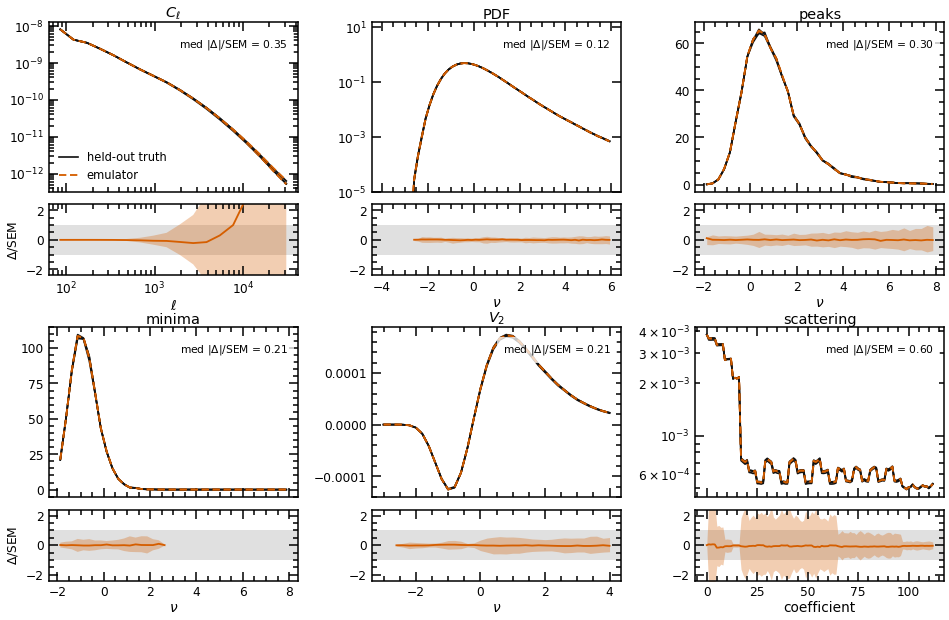

In [2]:
zi = 1
Vt, Vp, Vs = (V[k][:, zi].astype(np.float64) for k in ("truth", "pred", "sem"))
rng = np.random.default_rng(4)
show = rng.choice(R, 3, replace=False)
stats6 = ["Cl", "pdf", "peak", "min", "V2", "scat"]

fig = plt.figure(figsize=(10.5, 6.6))
gs = fig.add_gridspec(5, 3, height_ratios=[2.4, 1, 0.38, 2.4, 1], hspace=0.12, wspace=0.30)
for j, blk in enumerate(stats6):
    r0 = (j // 3) * 3
    ax = fig.add_subplot(gs[r0, j % 3])
    axr = fig.add_subplot(gs[r0 + 1, j % 3], sharex=ax)
    s, x = slices[blk], XCOORD[blk]
    for i, r in enumerate(show):
        ax.plot(x, Vt[r, s], color=C_TRUTH, lw=1.1,
                label="held-out truth" if (i == 0 and j == 0) else None)
        ax.plot(x, Vp[r, s], color=C_EMU, lw=1.2, ls=(0, (4, 2)),
                label="emulator" if (i == 0 and j == 0) else None)
    if blk == "Cl":
        ax.set_xscale("log"); ax.set_yscale("log")
    if blk == "pdf":
        ax.set_yscale("log"); ax.set_ylim(bottom=1e-5)
    if blk == "scat":
        ax.set_yscale("log")
    pop = Vs[:, s] > 0                                  # populated bins only
    zres = np.where(pop, (Vp[:, s] - Vt[:, s]) / np.where(pop, Vs[:, s], 1.0), np.nan)
    med = float(np.nanmedian(np.abs(zres)))
    ax.set_title(LABEL[blk], pad=2)
    ax.text(0.96, 0.85, rf"med $|\Delta|$/SEM = {med:.2f}", transform=ax.transAxes,
            ha="right", fontsize=7, bbox=dict(fc="white", ec="none", alpha=0.75))
    plt.setp(ax.get_xticklabels(), visible=False)

    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)   # all-NaN (never-populated) bins
        lo, mid, hi = np.nanpercentile(zres, [16, 50, 84], axis=0)
    sparse = np.isfinite(zres).mean(axis=0) < 0.5         # bins populated in <half the runs
    lo[sparse] = mid[sparse] = hi[sparse] = np.nan
    axr.axhspan(-1, 1, color=C_GRAY, alpha=0.30, lw=0)
    axr.plot(x, mid, color=C_EMU, lw=1.2)
    axr.fill_between(x, lo, hi, color=C_EMU, alpha=0.30, lw=0)
    axr.set_ylim(-2.4, 2.4); axr.set_yticks([-2, 0, 2])
    if blk == "Cl":
        axr.set_xscale("log")
    axr.set_xlabel({"Cl": r"$\ell$", "scat": "coefficient"}.get(blk, r"$\nu$"), labelpad=1)
    if j % 3 == 0:
        axr.set_ylabel(r"$\Delta$/SEM", fontsize=8)
ax0 = fig.axes[0]
ax0.legend(loc="lower left", handlelength=1.6)
save_fig(fig, "wlemu_fig1_multistat")

## Figure 2 — below the noise floor on every statistic, 5–100× beyond a map generator

(a) Distribution of held-out errors per statistic family, pooled over all 253
points × 5 source redshifts, in noise-floor units. The emulator's median error
is a *fraction* of the raytracing campaign's own uncertainty for every family,
and comparable to or below the cosmic-variance-only statistical error of an
LSST-Y10-area survey for most families (the scattering coefficients, whose
noise floor is already sub-percent, are the exception; shape noise would
loosen the survey lines, making these conservative).

(b) The same task attempted with other designs (identical pipeline,
historical fixed train/test split): nearest-neighbor look-up, quadratic
polynomial ridge, and the field-level generative route — a 1024² flow-matching
map emulator whose samples are then measured. The direct joint-statistics GP
is 5–100× more accurate per statistic than generating maps and measuring them.

*Caption draft*: (a) Held-out emulator error in units of the truth
noise floor (SEM of the 50-realization mean): median (dot), 16–84% (thick) and
5–95% (thin) ranges over all held-out points, redshifts, and populated bins.
Horizontal lines: the noise floor itself; the cosmic-variance-only statistical
error for Euclid-DR1-like (~1900 deg$^2$) and LSST-Y10-like (~18 000 deg$^2$)
areas, in the same units. (b) Mean fractional held-out error per statistic
family for this work vs alternative designs, including the field-level
generative-map route (measured at $z_s=1$).

  saved wlemu_fig2_accuracy


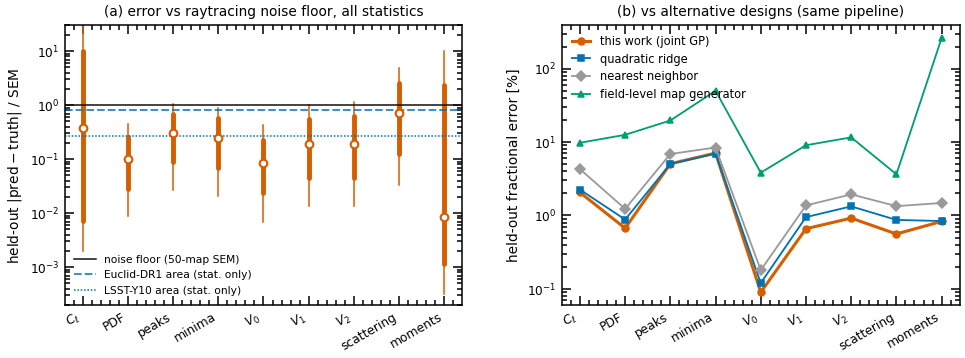

In [3]:
t_all = V["truth"].reshape(R * Z, D).astype(np.float64)
p_all = V["pred"].reshape(R * Z, D).astype(np.float64)
s_all = V["sem"].reshape(R * Z, D).astype(np.float64)
blocks = [str(b) for b in V["block_names"]]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.3), gridspec_kw=dict(wspace=0.25))

# (a) |err|/SEM interval plot (populated bins only)
ax = axes[0]
for i, b in enumerate(blocks):
    s = slices[b]
    pop = s_all[:, s] > 0
    zres = (np.abs(p_all[:, s] - t_all[:, s]) / np.where(pop, s_all[:, s], 1.0))[pop]
    q5, q16, q50, q84, q95 = np.percentile(zres, [5, 16, 50, 84, 95])
    ax.plot([i, i], [q5, q95], color=C_EMU, lw=1.0)
    ax.plot([i, i], [q16, q84], color=C_EMU, lw=3.2, solid_capstyle="round")
    ax.plot(i, q50, "o", color="white", mec=C_EMU, mew=1.4, ms=5, zorder=5)
ax.axhline(1.0, color=C_TRUTH, lw=1.0)
ref_handles = [Line2D([], [], color=C_TRUTH, lw=1.0, label="noise floor (50-map SEM)")]
for nt, lab, ls in [(76, "Euclid-DR1 area (stat. only)", (0, (5, 2))),
                    (720, "LSST-Y10 area (stat. only)", (0, (1, 1.2)))]:
    y = np.sqrt(50.0 / nt)
    ax.axhline(y, color=C_ALT, lw=1.0, ls=ls)
    ref_handles.append(Line2D([], [], color=C_ALT, lw=1.0, ls=ls, label=lab))
ax.set_yscale("log")
ax.set_ylim(2e-4, 30)
ax.set_xticks(range(len(blocks)), [LABEL[b] for b in blocks], rotation=30, ha="right")
ax.set_ylabel(r"held-out $|\mathrm{pred}-\mathrm{truth}|$ / SEM")
ax.legend(handles=ref_handles, loc="lower left", fontsize=7)
ax.set_title("(a) error vs raytracing noise floor, all statistics", fontsize=9)

# (b) design comparison (historical fixed-split protocol; kappa_emu shootout)
ax = axes[1]
FRAC = {  # mean |pred-truth|/|truth| per block
    "this work (joint GP)": {"Cl": 0.0206, "pdf": 0.0067, "peak": 0.0506, "min": 0.0708,
                             "V0": 0.0009, "V1": 0.0066, "V2": 0.0092, "scat": 0.0056,
                             "moments": 0.0083},
    "quadratic ridge": {"Cl": 0.0225, "pdf": 0.0088, "peak": 0.0504, "min": 0.0696,
                        "V0": 0.0012, "V1": 0.0095, "V2": 0.0133, "scat": 0.0087,
                        "moments": 0.0084},
    "nearest neighbor": {"Cl": 0.0428, "pdf": 0.0123, "peak": 0.0688, "min": 0.0842,
                         "V0": 0.0018, "V1": 0.0137, "V2": 0.0194, "scat": 0.0134,
                         "moments": 0.0148},
    "field-level map generator": {"Cl": 0.0977, "pdf": 0.1255, "peak": 0.1967, "min": 0.4991,
                                  "V0": 0.0383, "V1": 0.0905, "V2": 0.1158, "scat": 0.0364,
                                  "moments": 2.6008},
}
STYLE = {"this work (joint GP)": (C_EMU, "o", 2.0),
         "quadratic ridge": (C_ALT, "s", 1.2),
         "nearest neighbor": (C_GRAY, "D", 1.2),
         "field-level map generator": (C_GREEN, "^", 1.2)}
xi = np.arange(len(blocks))
for name, d in FRAC.items():
    c, m, lw = STYLE[name]
    ax.plot(xi, [100 * d[b] for b in blocks], marker=m, ms=4.5, lw=lw, color=c, label=name)
ax.set_yscale("log")
ax.set_xticks(xi, [LABEL[b] for b in blocks], rotation=30, ha="right")
ax.set_ylabel("held-out fractional error [%]")
ax.set_title("(b) vs alternative designs (same pipeline)", fontsize=9)
ax.legend(loc="upper left", handlelength=1.6)
save_fig(fig, "wlemu_fig2_accuracy")

## Figure 3 — one smooth surface: coherent feedback response of every statistic

Sweeping single feedback dials across the full SB35 prior (all other
parameters fiducial): supernova wind speed ($A_{\rm SN2}$, top) and AGN/BH
radiative efficiency (bottom), for four statistic families. Each panel shows
the per-bin response **in units of the statistical (cosmic-variance-only)
error of an LSST-Y10-area survey** (gray band = ±1; shared symlog scale), with
the integrated $S/N=\sqrt{\sum_{\rm bins}(\Delta/\sigma)^2}$ of the extreme
sweep annotated. At survey precision, feedback is a many-$\sigma$ effect not
just in the power spectrum but in *every* statistic family simultaneously —
if HOS enter a survey's data vector, their feedback response must be modeled
as consistently as the 2-pt one. This joint, smooth response surface is
exactly that model.

*Caption draft*: Response of the joint statistic suite to two feedback
parameters, each swept across its full prior range (color scale; all other
parameters fiducial), at $z_s = 1$, per bin in units of the statistical
error of an LSST-Y10-like area (18 000 deg$^2$ of independent 5×5 deg fields,
cosmic variance only — shape noise and systematics would loosen this, so the
scale is an idealized information measure). Gray band: $\pm 1\sigma$; note
the symlog scale. Annotations give the integrated $S/N$ of the largest
response in each panel. Peaks/PDF/Minkowski are measured in per-map $S/N$
units ($\nu$), so amplitude information is carried separately by the moments
block. Per-bin structure inside the gray band is comparable to the emulator's
own predictive uncertainty at this precision. Because all statistics are
emulated jointly from the same raytraced maps, their responses are mutually
consistent by construction.

  saved wlemu_fig3_response


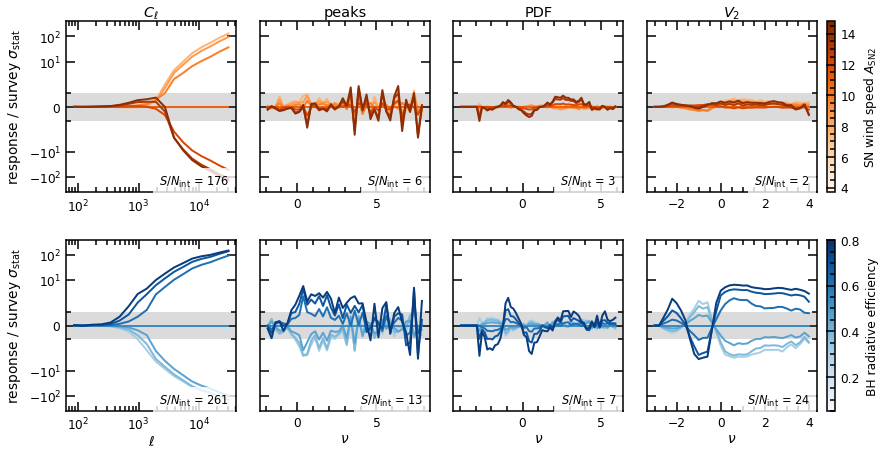

In [4]:
zi = 1
import warnings
warnings.filterwarnings("ignore", message="All values for SymLogScale")  # shared-y setup order
p0v = emu.predict_vector(emu.fiducial_params(), z_idx=zi, return_std=False)[0]
N_TILES = 18000 / 25.0                      # LSST-Y10-like area in 5x5 deg fields
sig = np.sqrt(np.diag(emu.covariance(z_idx=zi)) / N_TILES)   # survey stat. error
ok = sig > 0
SWEEP = [("VariableWindVelFactor", r"SN wind speed $A_{\rm SN2}$", "Oranges"),
         ("BlackHoleRadiativeEfficiency", "BH radiative efficiency", "Blues")]
COLS = ["Cl", "peak", "pdf", "V2"]
nv = 7

fig, axes = plt.subplots(2, 4, figsize=(10.5, 4.6), sharey=True,
                         gridspec_kw=dict(wspace=0.14, hspace=0.28))
for row, (name, nice, cmap) in enumerate(SWEEP):
    i = emu.param_names.index(name)
    thetas = np.tile(emu.fiducial_params(), (nv, 1))
    thetas[:, i] = np.linspace(0.0, 1.0, nv)
    phys = emu.unit_to_physical(thetas)[:, i]
    vr = emu.predict_vector(thetas, z_idx=zi, return_std=False)      # (nv, D)
    zresp = np.where(ok, (vr - p0v) / np.where(ok, sig, 1.0), 0.0)
    shades = plt.get_cmap(cmap)(np.linspace(0.35, 0.95, nv))
    for col, blk in enumerate(COLS):
        ax = axes[row, col]
        s, x = slices[blk], XCOORD[blk]
        for j in range(nv):
            ax.plot(x, zresp[j, s], color=shades[j], lw=1.3)
        ax.axhspan(-1, 1, color=C_GRAY, alpha=0.35, lw=0)
        sn = np.sqrt((zresp[:, s] ** 2).sum(axis=1)).max()
        ax.text(0.96, 0.04, rf"$S/N_{{\rm int}}$ = {sn:.0f}", transform=ax.transAxes,
                ha="right", fontsize=7.5, bbox=dict(fc="white", ec="none", alpha=0.8))
        ax.set_yscale("symlog", linthresh=2)
        ax.set_ylim(-400, 400)
        ax.set_yticks([-100, -10, 0, 10, 100])
        if blk == "Cl":
            ax.set_xscale("log")
        if col == 0:
            ax.set_ylabel(r"response / survey $\sigma_{\rm stat}$")
        if row == 0:
            ax.set_title(LABEL[blk], pad=3)
        if row == 1:
            ax.set_xlabel(r"$\ell$" if blk == "Cl" else r"$\nu$", labelpad=1)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(phys.min(), phys.max()))
    cb = fig.colorbar(sm, ax=axes[row, :].tolist(), pad=0.012, aspect=22)
    cb.set_label(nice, fontsize=8)
save_fig(fig, "wlemu_fig3_response")

## Figure 4 — self-consistency and the closed inference loop

(a) Parameter-driven fluctuations of three *different* statistic families
across all 253 held-out points — high-$\ell$ power, high-significance peak
abundance, map rms — truth vs emulator. The emulator tracks each axis and
preserves the cross-statistic correlation structure (truth correlations are
mildly diluted by residual per-point generation noise).

(b) Closing the loop: a held-out simulation's $C_\ell$+peaks as pseudo-data,
the emulator as theory, the shipped single-field covariance (+ the emulator's
predictive variance, Hartlap-corrected) as the noise model. Repeating over the
12 most central held-out points, the truth falls inside the 68% contour for
11/12 — unbiased end-to-end recovery of feedback parameters from WL
statistics alone.

*Caption draft*: (a) Fluctuations (relative to the ensemble mean) of three
integrated statistics across the 253 held-out parameter points: raytraced
truth vs emulator prediction; the legend gives the correlation per statistic.
(b) Conditional 68/95% constraints on the two dominant feedback parameters
from one 5×5 deg field ($C_\ell$ + peak counts) for a representative held-out
simulation; the cross marks its true parameters. Across the 12 most central
held-out points, 11/12 truths fall inside the 68% region.

  saved wlemu_fig4_joint
coverage: 11/12 in 68%, 11/12 in 95%; shown: held-out point 160


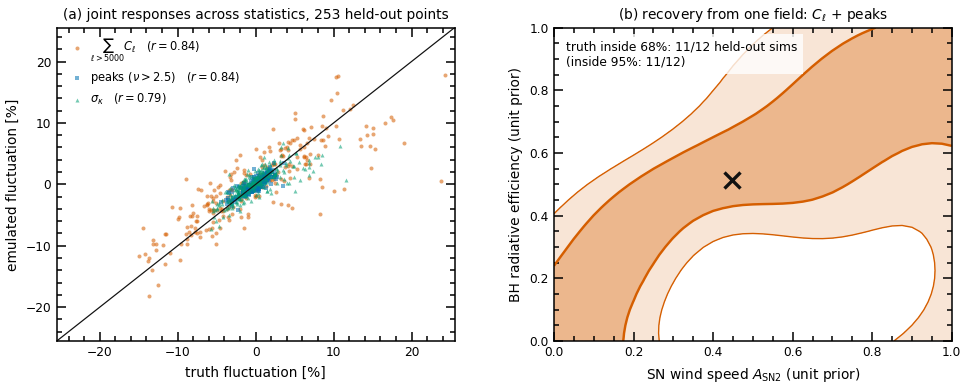

In [5]:
zi = 1
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7), gridspec_kw=dict(wspace=0.25))

# (a) cross-statistic response fluctuations, truth vs emulator
W = np.zeros((3, D))
W[0, np.arange(D)[slices["Cl"]][V["ell"] > 5e3]] = 1
W[1, np.arange(D)[slices["peak"]][V["peak_x"] > 2.5]] = 1
W[2, np.arange(D)[slices["moments"]][1]] = 1
FLAB = [r"$\sum_{\ell>5000} C_\ell$", r"peaks ($\nu>2.5$)", r"$\sigma_\kappa$"]
Ft = V["truth"][:, zi].astype(np.float64) @ W.T
Fp = V["pred"][:, zi].astype(np.float64) @ W.T
rt, rp = 100 * (Ft / Ft.mean(0) - 1), 100 * (Fp / Ft.mean(0) - 1)
ax = axes[0]
for j, (c, m) in enumerate([(C_EMU, "o"), (C_ALT, "s"), (C_GREEN, "^")]):
    r = np.corrcoef(rt[:, j], rp[:, j])[0, 1]
    ax.scatter(rt[:, j], rp[:, j], s=7, color=c, marker=m, alpha=0.55, lw=0,
               label=f"{FLAB[j]}   ($r={r:.2f}$)")
lim = 1.05 * max(np.abs(rt).max(), np.abs(rp).max())
ax.plot([-lim, lim], [-lim, lim], color=C_TRUTH, lw=0.8)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("truth fluctuation [%]"); ax.set_ylabel("emulated fluctuation [%]")
ax.legend(loc="upper left", handletextpad=0.1, borderpad=0.3)
ax.set_title("(a) joint responses across statistics, 253 held-out points", fontsize=9)

# (b) closed-loop inference + coverage
scan = ["VariableWindVelFactor", "BlackHoleRadiativeEfficiency"]
pa, pb = (emu.param_names.index(n) for n in scan)
run_true = V["params_unit"].astype(np.float64)
mask_cl = np.zeros(D, bool); mask_cl[slices["Cl"]] = True
peak_mean = V["truth"][:, zi, slices["peak"]].mean(0)
mask_pk = np.zeros(D, bool)
mask_pk[np.arange(D)[slices["peak"]][peak_mean > 30]] = True
mask = mask_cl | mask_pk
cov0 = np.zeros((D, D))
idx_all = np.concatenate([np.arange(D)[slices["Cl"]], np.arange(D)[slices["peak"]]])
cov0[np.ix_(idx_all, idx_all)] = emu.covariance(z_idx=zi, blocks=("Cl", "peak"))
hartlap = (emu.n_real - mask.sum() - 2) / (emu.n_real - 1)

def chi2_grid(r_obs, n=41):
    theta_true = run_true[r_obs]
    obs = V["truth"][r_obs, zi].astype(np.float64)
    _, sd_gp = emu.predict_vector(theta_true, z_idx=zi)
    cv = cov0.copy(); cv[np.diag_indices(D)] += np.atleast_2d(sd_gp)[0] ** 2
    Ci = hartlap * np.linalg.inv(cv[np.ix_(mask, mask)])
    g = np.linspace(0, 1, n)
    A, B = np.meshgrid(g, g, indexing="ij")
    th = np.tile(theta_true, (n * n, 1))
    th[:, pa], th[:, pb] = A.ravel(), B.ravel()
    d = (emu.predict_vector(th, z_idx=zi, return_std=False) - obs)[:, mask]
    return g, np.einsum("nd,de,ne->n", d, Ci, d).reshape(n, n)

cand = np.argsort(((run_true[:, [pa, pb]] - 0.5) ** 2).sum(1))[:12]
dvals = []
for r in cand:
    g, c2 = chi2_grid(int(r))
    ia, ib = (int(round(run_true[r, j] * (len(g) - 1))) for j in (pa, pb))
    dvals.append(float((c2 - c2.min())[ia, ib]))
dvals = np.array(dvals)
n68, n95 = (dvals < 2.30).sum(), (dvals < 6.17).sum()

r_show = int(cand[np.argmin(np.abs(dvals - np.median(dvals)))])
g, c2 = chi2_grid(r_show)
ax = axes[1]
ax.contourf(g, g, (c2 - c2.min()).T, levels=[0, 6.17], colors=[C_EMU], alpha=0.16)
ax.contourf(g, g, (c2 - c2.min()).T, levels=[0, 2.30], colors=[C_EMU], alpha=0.34)
ax.contour(g, g, (c2 - c2.min()).T, levels=[2.30, 6.17], colors=C_EMU,
           linewidths=[1.6, 0.9])
ax.plot(*run_true[r_show, [pa, pb]], marker="x", ms=10, mew=2.2, color=C_TRUTH, ls="none")
ax.text(0.03, 0.96, f"truth inside 68%: {n68}/12 held-out sims\n"
        f"(inside 95%: {n95}/12)", transform=ax.transAxes, va="top", fontsize=8,
        bbox=dict(fc="white", ec="none", alpha=0.8))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel(r"SN wind speed $A_{\rm SN2}$ (unit prior)")
ax.set_ylabel("BH radiative efficiency (unit prior)")
ax.set_title(r"(b) recovery from one field: $C_\ell$ + peaks", fontsize=9)
save_fig(fig, "wlemu_fig4_joint")
print(f"coverage: {n68}/12 in 68%, {n95}/12 in 95%; shown: held-out point {r_show}")

## Numbers for the text (LaTeX table)

Per-statistic held-out accuracy, pooled over all 253 points × 5 source
redshifts (k-fold protocol).

In [6]:
import pandas as pd
from bind.wlemu.fit import frac_err_by_block, sigma_err_by_block

frac = frac_err_by_block(t_all, p_all, slices)
sig_ = sigma_err_by_block(t_all, p_all, s_all, slices)
floor = {k: float(np.mean((s_all[:, s] / np.maximum(np.abs(t_all[:, s]), 1e-300))
                          [np.abs(t_all[:, s]) > 1e-6 * np.abs(t_all[:, s]).max()]))
         for k, s in slices.items()}
tab = pd.DataFrame({
    "frac err [%]": {k: 100 * v for k, v in frac.items()},
    "median err/SEM": sig_,
    "noise floor [%]": {k: 100 * v for k, v in floor.items()},
}).round(2)
print(tab.to_latex(float_format="%.2f"))
tab

\begin{tabular}{lrrr}
\toprule
 & frac err [%] & median err/SEM & noise floor [%] \\
\midrule
Cl & 1.98 & 0.37 & 2.58 \\
pdf & 0.79 & 0.10 & 5.09 \\
peak & 4.97 & 0.30 & 10.80 \\
min & 6.85 & 0.25 & 18.47 \\
V0 & 0.09 & 0.09 & 0.70 \\
V1 & 0.74 & 0.19 & 4.62 \\
V2 & 0.99 & 0.19 & 5.39 \\
scat & 0.60 & 0.71 & 0.58 \\
moments & 0.83 & 0.01 & 161.01 \\
\bottomrule
\end{tabular}



,frac err [%],median err/SEM,noise floor [%]
Cl,1.98,0.37,2.58
pdf,0.79,0.10,5.09
peak,4.97,0.30,10.80
min,6.85,0.25,18.47
V0,0.09,0.09,0.70
V1,0.74,0.19,4.62
V2,0.99,0.19,5.39
scat,0.60,0.71,0.58
moments,0.83,0.01,161.01
